# Whakaari Cause–Trigger Analysis

This notebook applies the Cause–Trigger algorithm to the Whakaari 2019 eruption case. 

The full dataset is retained as the constructed data product, but the algorithm is applied only to a fixed case-study interval \(I\). The split into \(I_1\) and \(I_2\) is selected automatically from the effect variable.

## 1. Imports, paths, and case-study interval

In [20]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "whakaari"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_whakaari import *

EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")
WHAKAARI_PATH = DATA_DIR / "whakaari_final.csv"

In [21]:
X_full = load_model_frame(WHAKAARI_PATH)

CASE_START = EVENT_TIME - pd.Timedelta(days=7)
CASE_END = EVENT_TIME + pd.Timedelta(hours=48)

X = X_full.loc[CASE_START:CASE_END].copy()

display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,216,8,2019-12-02 02:00:00+00:00,2019-12-11 01:00:00+00:00,h,effect_tremor_5_15_scaled,-2.781635,0.669098,0.088066,2.154482,1.054493,1.843784,216


## 2. Reference lag selection

VAR-AIC and VAR-BIC are reported as automatic reference lags. The final interpretation is based on whether the result is stable across nearby lags in the 1–12 grid.

In [22]:
MAX_LAGS = 12

reference_parameters = pd.DataFrame([
    select_parameters(
        X,
        EFFECT,
        max_lags=MAX_LAGS,
        criterion="aic",
        fallback_lag=1,
        fallback_distribution="gaussian",
    ),
    select_parameters(
        X,
        EFFECT,
        max_lags=MAX_LAGS,
        criterion="bic",
        fallback_lag=1,
        fallback_distribution="gaussian",
    ),
])

display(reference_parameters)

aic_row = reference_parameters.loc[
    reference_parameters["lag_method"] == "VAR-AIC"
].iloc[0]

selected_lag = int(aic_row["selected_lag"])
selected_distribution = aic_row["selected_distribution"]

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


,effect,selected_lag,selected_distribution,lag_method,max_lags,fallback_lag,fallback_distribution
0,effect_tremor_5_15_scaled,12,gaussian,VAR-AIC,12,1,gaussian
1,effect_tremor_5_15_scaled,2,gaussian,VAR-BIC,12,1,gaussian


## 3. Main configuration and automatic split

The split is selected automatically inside the fixed Whakaari case-study interval. The known eruption time is shown only as external context.

Rows in X: 216
Required minimum: 78


,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split,split_end_index,split_end_time,split_score,signed_mean_I1,signed_mean_I2
0,effect_tremor_5_15_scaled,170,2019-12-09 04:00:00+00:00,170,46,0.530921,1.548575,1.017654,2019-12-09 01:11:00+00:00,0 days 02:49:00,False,216,2019-12-11 01:00:00+00:00,1.017654,0.530921,-1.548575


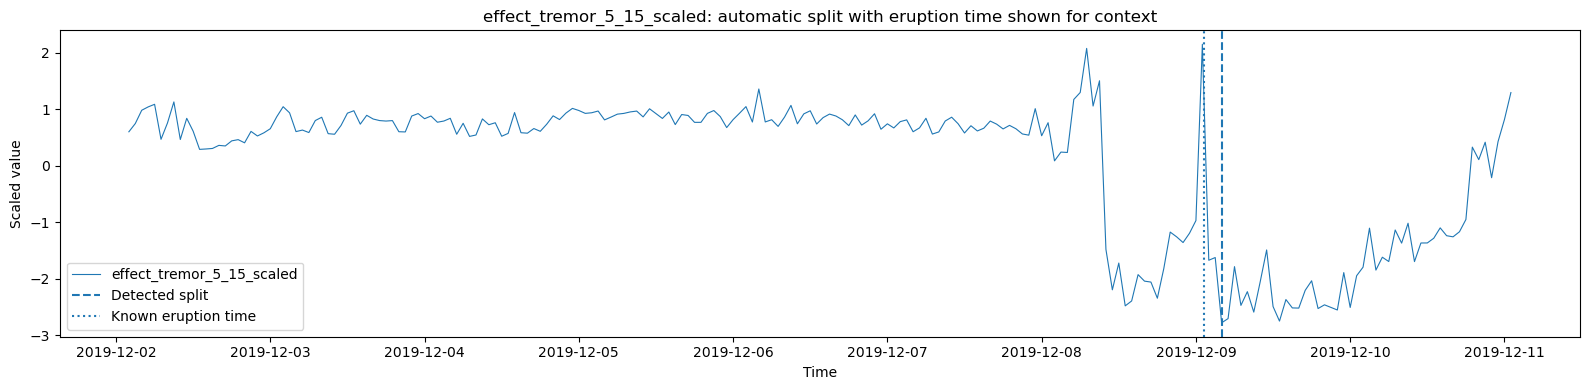

In [23]:
workflow = WhakaariWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    selected_lag=selected_lag,
    max_lags=MAX_LAGS,
    min_I1_length=48,
    min_I2_length=30,
    distribution=selected_distribution,
    parameter_source="automatic_reference",
)

print("Rows in X:", len(X))
print("Required minimum:", workflow.min_I1_length + workflow.min_I2_length)

assert len(X) >= workflow.min_I1_length + workflow.min_I2_length

main_split = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([main_split]))

plot_effect_with_split(
    X,
    EFFECT,
    main_split,
    event_time=workflow.event_time,
)

## 4. Reference-lag backend comparison

This run shows the result at the VAR-AIC reference lag. The result is considered stronger if the same pair also appears across adjacent lags in the stability grid.

In [24]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    lag=workflow.selected_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

display(compact_comparison(comparison))
display(compact_diagnostics(diagnostics))

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\cescedes\anaconda3\envs\M\Lib\s

,run,backend,configured_lags,configured_distribution,split_timestamp,I1_length,I2_length,B2,trigger_candidates,accepted_triggers,causes,pairs,stop_reason
0,hmml_backend_beta,hmml,12,gaussian,2019-12-09 04:00:00+00:00,170,46,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...",[],[],[],[],No lagged or contemporaneous trigger candidate...
1,pcmci_ridge,pcmci,12,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],No lagged non-target B2 variables available to...
2,pcmci_plus_ridge,pcmci_plus,12,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],No lagged non-target B2 variables available to...


""


## 5. HMML lag-stability grid

The HMML backend is used as the baseline. A pair is considered stable if it appears over at least two adjacent lags.

In [25]:
hmml_sensitivity = run_sensitivity_grid(
    X,
    workflow,
    run_specs=({"run": "hmml_backend_beta", "backend": "hmml"},),
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
)

hmml_accepted = accepted_sensitivity_rows(hmml_sensitivity)
hmml_stability = summarise_lag_stability(
    hmml_sensitivity,
    backend="hmml",
    reference_lag=workflow.selected_lag,
    min_adjacent=2,
)

display(hmml_accepted)
display(hmml_stability)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links,error
2,hmml_backend_beta,hmml,3,gaussian,2019-12-09 04:00:00+00:00,170,46,"[API_scaled, SO2_flux_scaled]",[API_scaled],[API_scaled],[],[API_scaled],[SO2_flux_scaled],"[(SO2_flux_scaled, API_scaled)]",1.022220e-08,0.563757,0,None


,pair,cause,trigger,lags,n_lags,stable,stable_clusters,reference_lag,reference_lag_in_stable_cluster,recommended_lag,recommendation_source,min_p_value,max_rss_reduction_ratio
0,"(SO2_flux_scaled, API_scaled)",SO2_flux_scaled,API_scaled,[3],1,False,[],12,False,None,not_stable,1.022220e-08,0.563757


In [26]:
if not hmml_stability.empty and hmml_stability["stable"].any():
    representative_lag = int(
        hmml_stability.loc[hmml_stability["stable"], "recommended_lag"].iloc[0]
    )
    representative_pair = hmml_stability.loc[hmml_stability["stable"], "pair"].iloc[0]
else:
    representative_lag = workflow.selected_lag
    representative_pair = None

summary_choice = pd.DataFrame([{
    "reference_lag_VAR_AIC": workflow.selected_lag,
    "representative_lag": representative_lag,
    "representative_pair": representative_pair,
}])

display(summary_choice)

,reference_lag_VAR_AIC,representative_lag,representative_pair
0,12,12,None


## 6. PCMCI lagged-link robustness

PCMCI is used as a stricter supplementary backend. This section uses only lagged PCMCI links and does not include contemporaneous trigger candidates.

In [27]:
pcmci_sensitivity = run_sensitivity_grid(
    X,
    workflow,
    run_specs=({"run": "pcmci_ridge", "backend": "pcmci"},),
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
    use_contemporaneous_triggers=False,
)

display(compact_sensitivity(pcmci_sensitivity))
display(accepted_sensitivity_rows(pcmci_sensitivity))

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\si

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links,error
0,pcmci_ridge,pcmci,1,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
1,pcmci_ridge,pcmci,2,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
2,pcmci_ridge,pcmci,3,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
3,pcmci_ridge,pcmci,4,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
4,pcmci_ridge,pcmci,5,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
5,pcmci_ridge,pcmci,6,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
6,pcmci_ridge,pcmci,7,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
7,pcmci_ridge,pcmci,8,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
8,pcmci_ridge,pcmci,9,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None
9,pcmci_ridge,pcmci,10,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,0,None


""


## 7. PCMCI+ contemporaneous-trigger extension

PCMCI+ is used as a separate supplementary extension because it can estimate contemporaneous \(tau=0\) links. In this section, significant contemporaneous source-target links are allowed as immediate trigger candidates. They are not added to \(B_2\), and \(V\) is still constructed only from lagged \(B_2\) parents.

In [28]:
pcmci_plus_tau0_sensitivity = run_sensitivity_grid(
    X,
    workflow,
    run_specs=({"run": "pcmci_plus_tau0_ridge", "backend": "pcmci_plus"},),
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
    use_contemporaneous_triggers=True,
)

display(compact_sensitivity(pcmci_plus_tau0_sensitivity))
display(accepted_sensitivity_rows(pcmci_plus_tau0_sensitivity))

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\si

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links,error
0,pcmci_plus_tau0_ridge,pcmci_plus,1,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,1,None
1,pcmci_plus_tau0_ridge,pcmci_plus,2,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,1,None
2,pcmci_plus_tau0_ridge,pcmci_plus,3,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,1,None
3,pcmci_plus_tau0_ridge,pcmci_plus,4,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,1,None
4,pcmci_plus_tau0_ridge,pcmci_plus,5,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,1,None
5,pcmci_plus_tau0_ridge,pcmci_plus,6,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,1,None
6,pcmci_plus_tau0_ridge,pcmci_plus,7,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,1,None
7,pcmci_plus_tau0_ridge,pcmci_plus,8,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,2,None
8,pcmci_plus_tau0_ridge,pcmci_plus,9,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,2,None
9,pcmci_plus_tau0_ridge,pcmci_plus,10,gaussian,2019-12-09 04:00:00+00:00,170,46,[],[],[],[],[],[],[],None,None,2,None


""
